
--- Gaussian NB ---
Accuracy: 0.875945537065053
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.58      0.67       436
           1       0.89      0.96      0.92      1547

    accuracy                           0.88      1983
   macro avg       0.84      0.77      0.80      1983
weighted avg       0.87      0.88      0.87      1983

Confusion Matrix:
 [[ 255  181]
 [  65 1482]]

--- Multinomial NB ---
Accuracy: 0.7987897125567323
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.19      0.30       436
           1       0.81      0.97      0.88      1547

    accuracy                           0.80      1983
   macro avg       0.73      0.58      0.59      1983
weighted avg       0.77      0.80      0.75      1983

Confusion Matrix:
 [[  84  352]
 [  47 1500]]

--- Bernoulli NB ---
Accuracy: 0.8350983358547656
Classification Report:
               precision    re

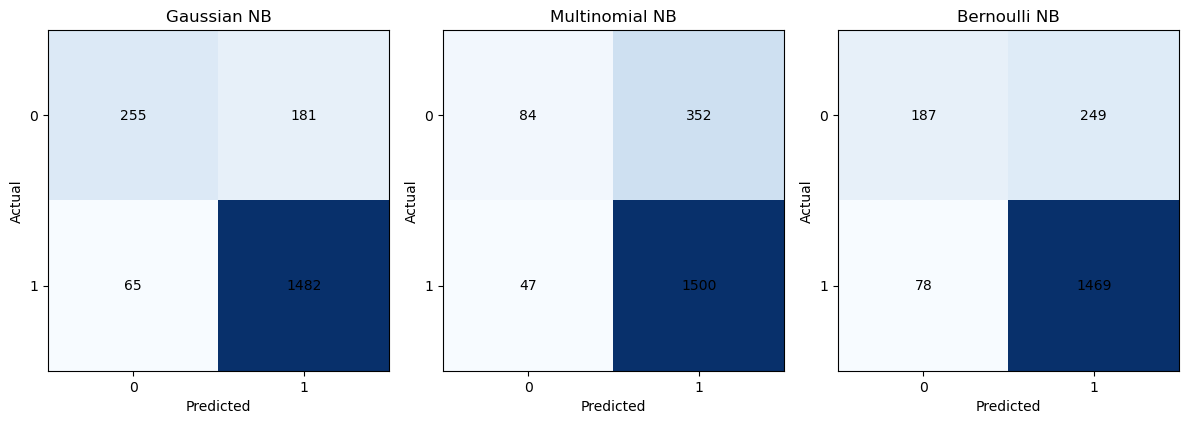

Number of trials in the main dataset:  (6607, 8)
Number of trials in the Test dataset:  (1983, 7)
Number of trials in the Train dataset:  (4624, 7)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB


#---------------------------
# Load, Label and Save
#---------------------------

df = pd.read_csv("C:/Users/User/Desktop/Machine Learning/dataset1_cleaned_numeric.csv")
df["Pass"] = (df["Exam_Score"] >= 65).astype(int)
Altered_path = "C:/Users/User/Machine/Jupyter file/Supervised learning/dataset1_cleaned_altered_NB.csv"
df.to_csv(Altered_path, index = False)

#---------------------------
# Gaussian NB
#---------------------------

df_gnb = df.copy()
X_gnb = df_gnb.drop(["Exam_Score", "Pass"], axis=1)
y_gnb = df_gnb["Pass"]

df_gnb.to_csv("gnb_data.csv", index = False)
#---------------------------
# Multinomial NB
#---------------------------

df_mnb = df.copy()

for col in ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores", "Tutoring_Sessions", "Physical_Activity"]:
    df_mnb[col] = pd.qcut(df_mnb[col], q=4, labels=False, duplicates="drop")

X_mnb = df_mnb.drop(["Exam_Score", "Pass"], axis=1)
y_mnb = df_mnb["Pass"]

df_mnb.to_csv("mnb_data.csv", index = False)
#------------------------------
# bernullie NB
#-------------------------------

df_bnb = df.copy()

for col in ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores", "Tutoring_Sessions", "Physical_Activity"]:
    df_bnb[col] = (df_bnb[col] >= df_bnb[col].median()).astype(int)

X_bnb = df_bnb.drop(["Exam_Score", "Pass"], axis=1)
y_bnb = df_bnb["Pass"]

df_bnb.to_csv("bnb_data.csv", index = False)
#-------------------------------
# train and test
#-------------------------------

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_gnb, y_gnb, test_size=0.3, random_state=42, stratify=y_gnb
)

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_mnb, y_mnb, test_size=0.3, random_state=42, stratify=y_mnb
)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bnb, y_bnb, test_size=0.3, random_state=42, stratify=y_bnb
)


# Gaussian NB
gnb = GaussianNB()
gnb.fit(Xg_train, yg_train)
pred_gnb = gnb.predict(Xg_test)
acc_gnb = accuracy_score(yg_test, pred_gnb)

# Multinomial NB
mnb = MultinomialNB()
mnb.fit(Xm_train, ym_train)
pred_mnb = mnb.predict(Xm_test)
acc_mnb = accuracy_score(ym_test, pred_mnb)

# Bernoulli NB
bnb = BernoulliNB()
bnb.fit(Xb_train, yb_train)
pred_bnb = bnb.predict(Xb_test)
acc_bnb = accuracy_score(yb_test, pred_bnb)

#pred_bnb.to_csv("bnb_prediction.csv", index = False)


#-----------------------------
# evaluation
#-----------------------------

def evaluate_model(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)
    return cm

cm_gnb = evaluate_model("Gaussian NB", yg_test, pred_gnb)
cm_mnb = evaluate_model("Multinomial NB", ym_test, pred_mnb)
cm_bnb = evaluate_model("Bernoulli NB", yb_test, pred_bnb)

print("\n===== Model Comparison =====")
print(f"Gaussian NB Accuracy:     {acc_gnb:.4f}")
print(f"Multinomial NB Accuracy:  {acc_mnb:.4f}")
print(f"Bernoulli NB Accuracy:    {acc_bnb:.4f}")
#-----------------------------
# confusion matrix
#-----------------------------

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

cms = [cm_gnb, cm_mnb, cm_bnb]
titles = ["Gaussian NB", "Multinomial NB", "Bernoulli NB"]

for ax, cm, title in zip(axes, cms, titles):
    ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for i in range(len(cm)):
        for j in range(len(cm[0])):
            ax.text(j, i, cm[i][j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

#--------------------------------------------
# Saving the train-test data for Gaussian
#--------------------------------------------
train_gnb = Xg_train.copy()
train_gnb["Pass"] = yg_train.values

test_gnb = Xg_test.copy()
test_gnb["Pass"] = yg_test.values


print("Number of trials in the main dataset: ", df.shape)
print("Number of trials in the Test dataset: ", test_gnb.shape)
print("Number of trials in the Train dataset: ", train_gnb.shape)

train_gnb.to_csv("train_gnb.csv", index=False)
test_gnb.to_csv("test_gnb.csv", index=False)

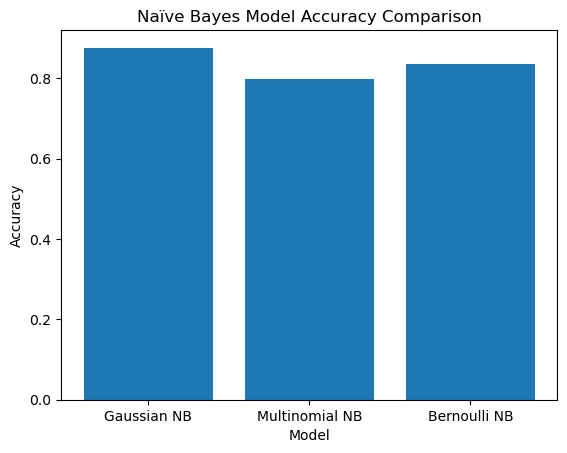

In [4]:
import matplotlib.pyplot as plt

models = ["Gaussian NB", "Multinomial NB", "Bernoulli NB"]
accuracies = [acc_gnb, acc_mnb, acc_bnb]

plt.figure()
plt.bar(models, accuracies)
plt.title("Naïve Bayes Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()